# Bayesian HUD Statistics

## Introduction

- HUD accumulates stats over thousands of hands; villain sample sizes are much smaller
- Three stages: full sample → villain appearances → stat-specific opportunities within those appearances
- All stats are conditional; difference is how often the condition is met (VPIP nearly always, 3B ~15% of hands)
- SNR depends on both sample size and population spread sigma: small sigma means even large samples may not reveal genuine deviation from the mean
- Three use cases: single-stat filtering, archetype-based filtering, within-hand updating

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from bayesian_hud.archetypes import (
    ARCHETYPE_NAMES, STAT_NAMES, get_archetype_params
)
from bayesian_hud.single_stat import (
    _population_priors,
    plot_estimation_comparison, plot_shrinkage_curves, plot_rmse_vs_hands
)
from bayesian_hud.multi_stat import (
    plot_population_scatter, plot_variance_decomposition,
    plot_correlation_structure,
    plot_archetype_posteriors_line, plot_stat_informativeness,
    plot_rmse_by_archetype, plot_rmse_unconditional,
)
from bayesian_hud.decision_tree import (
    plot_posterior_evolution, plot_path_tree, trace_path
)

## Single-Stat Bayesian Filtering

### Model

We model each player's true rate $\theta$ for a given stat as drawn from a population prior $\theta \sim \mathcal{N}(\mu, \sigma^2)$. After observing $k$ successes in $n$ opportunities the raw estimate is $\hat{\theta} = k/n$ with sampling noise $\hat{s} = \sqrt{\hat{\theta}(1-\hat{\theta})/n}$. We use Laplace smoothing $\hat{\theta} = (k + 0.5)/(n + 1)$ to avoid degenerate zero estimates at the boundary. Under the Gaussian conjugate model the posterior mean is the shrinkage estimator:
$$\theta_B = \mu + w\,(\hat{\theta} - \mu), \qquad w = \frac{\sigma^2}{\sigma^2 + \hat{s}^2}$$
This is a proper Bayesian posterior mean: a precision-weighted average of the prior mean and the observed frequency, where precision $= 1/\text{variance}$.

- $\mu$ and $\sigma$ are estimated from the full database as the unconditional population mean and variance. We assume a unimodal Gaussian population — this assumption is revisited in the archetype section.

In [2]:
mu_pop, sigma_pop = _population_priors()
print("Population prior parameters:")
header = f"{'Stat':<8}  {'mu':>8}  {'sigma':>8}"
print(header)
print("-" * len(header))
for name, mu, sigma in zip(STAT_NAMES, mu_pop, sigma_pop):
    print(f"{name:<8}  {mu:>8.4f}  {sigma:>8.4f}")

Population prior parameters:
Stat            mu     sigma
----------------------------
VPIP        0.3315    0.1221
PFR         0.1630    0.0794
3B%         0.0720    0.0507


### Shrinkage weight

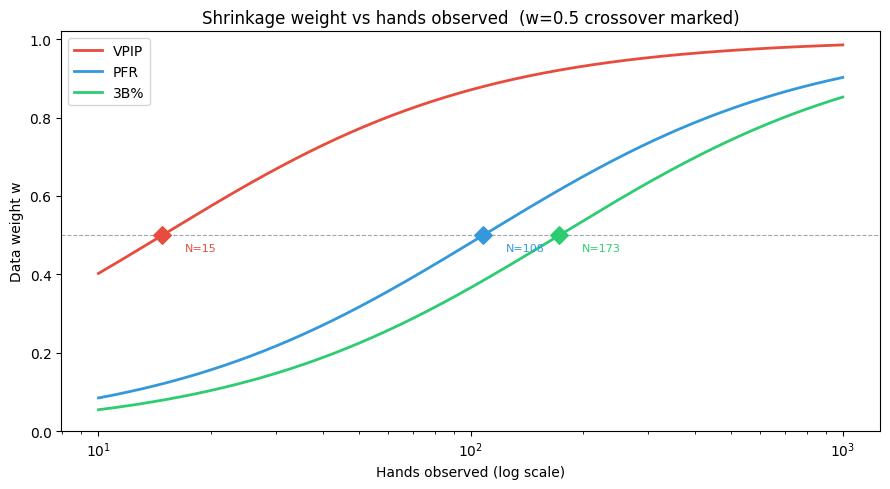

In [3]:
fig = plot_shrinkage_curves()
plt.show()

- Weight depends on both sample size and stat: VPIP shrinks slowly (high sigma), 3B shrinks quickly (low sigma, rare opportunities)
- Even at 500 opportunities the prior still contributes meaningfully for all stats

### Estimation

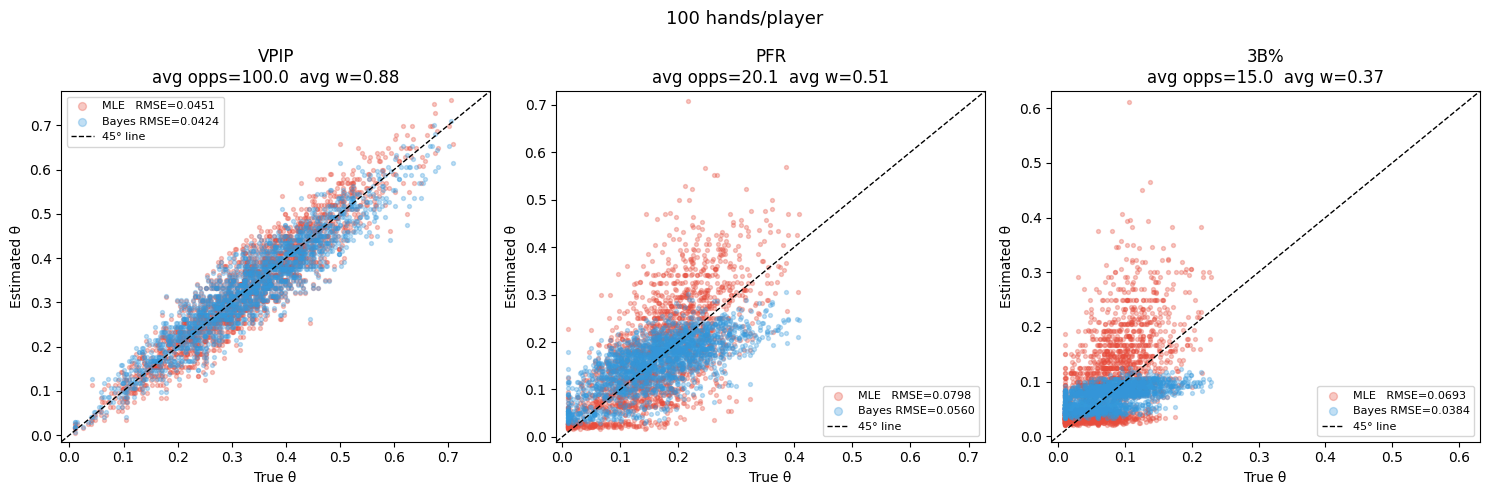

In [4]:
fig = plot_estimation_comparison(total_hands=100)
plt.show()

- N=100 hands but actual opportunities differ by stat: VPIP ~100, PFR ~20, 3B ~15
- Bayesian RMSE < MLE RMSE for all stats

### RMSE vs sample size

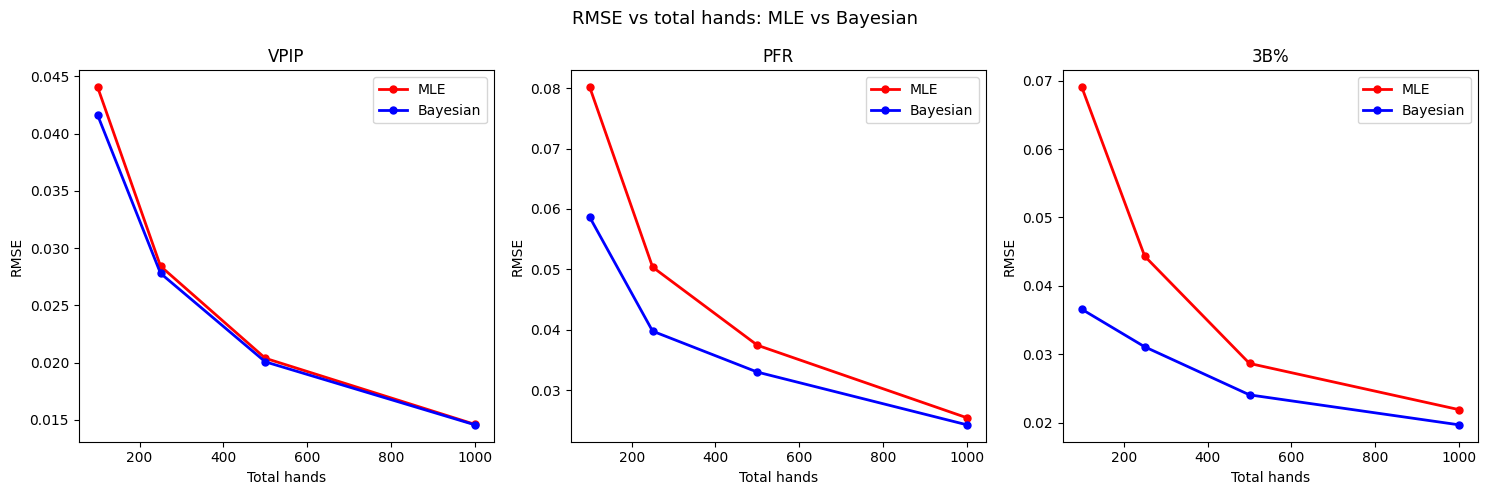

In [5]:
fig = plot_rmse_vs_hands()
plt.show()

- Bayesian consistently outperforms raw; gap narrows as N grows but prior never becomes irrelevant

## Archetype Definitions

- Population is multimodal — distinct player types
- K=3 archetypes: Fish (loose-passive), TAG (tight-aggressive), LAG (loose-aggressive)
- Parameters are illustrative; calibrate from your own database
- Note: unimodal Gaussian used in single-stat section has mean and variance matching the unconditional moments of this mixture

In [6]:
mu, sigma, pi = get_archetype_params()

header = f"{'Archetype':<8}  {'Weight':>6}  " + "  ".join(f"{s:>12}" for s in STAT_NAMES)
sep    = "-" * len(header)
print(header)
print(sep)
for k, name in enumerate(ARCHETYPE_NAMES):
    stat_cols = "  ".join(
        f"{mu[k,j]:.2f} +/- {sigma[k,j]:.2f}" for j in range(len(STAT_NAMES))
    )
    print(f"{name:<8}  {pi[k]:>6.0%}  {stat_cols}")
print(sep)
print(f"{'Total':<8}  {pi.sum():>6.0%}")

Archetype  Weight          VPIP           PFR           3B%
-----------------------------------------------------------
Fish         40%  0.45 +/- 0.08  0.10 +/- 0.06  0.03 +/- 0.03
TAG          45%  0.22 +/- 0.04  0.18 +/- 0.04  0.08 +/- 0.02
LAG          15%  0.35 +/- 0.05  0.28 +/- 0.05  0.16 +/- 0.03
-----------------------------------------------------------
Total       100%


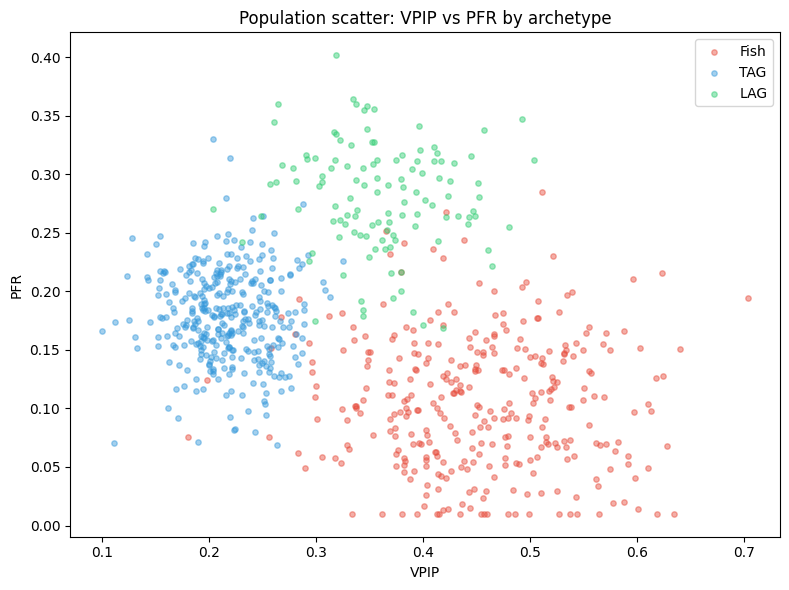

In [7]:
fig = plot_population_scatter()
plt.show()

- Visible clusters in VPIP/PFR space justify mixture model

## Archetype-Based Multi-Stat Filtering

### Model

Rather than a single population prior, we maintain a discrete posterior over archetypes updated jointly on all three stats.

The total variance of $\hat{\theta}_j$ under archetype $k$ accounts for both the prior spread and the sampling noise:
$$v_{kj} = \sigma_{kj}^2 + \hat{s}_j^2, \qquad \hat{s}_j = \sqrt{\frac{\hat{\theta}_j(1-\hat{\theta}_j)}{n_j}}$$

The log-likelihood of the observed vector $\hat{\boldsymbol{\theta}}$ under archetype $k$ is:
$$\log p(\hat{\boldsymbol{\theta}} \mid k) = \sum_j \log \mathcal{N}\!\left(\hat{\theta}_j;\; \mu_{kj},\; v_{kj}\right)$$

and the posterior is:
$$P(k \mid \hat{\boldsymbol{\theta}}) \propto \pi_k \cdot p(\hat{\boldsymbol{\theta}} \mid k)$$

The final estimate for stat $j$ is the archetype-posterior-weighted shrinkage:
$$\hat{\theta}^{\text{arch}}_j = \sum_k P(k \mid \hat{\boldsymbol{\theta}})\cdot \hat{\theta}^B_{kj}$$

where $\hat{\theta}^B_{kj}$ is the per-archetype shrinkage estimate.

### Intra- vs inter-archetype variation

In [8]:
plot_variance_decomposition()

Variance decomposition: within vs between archetype
────────────────────────────────────────────────────
Stat        Between     Within      Total    B/(B+W)
────────────────────────────────────────────────────
VPIP         0.0113     0.0037     0.0149       0.75
PFR          0.0038     0.0025     0.0063       0.60
3B           0.0019     0.0007     0.0026       0.74
────────────────────────────────────────────────────


- The table above shows the variance decomposition computed analytically from archetype parameters
- Between-archetype variance is the component driven by different archetype means; within-archetype variance reflects how much individuals vary around their archetype mean
- Stats with high between/(between+within) ratio discriminate well: a single observation shifts the archetype posterior substantially

### Covariance structure

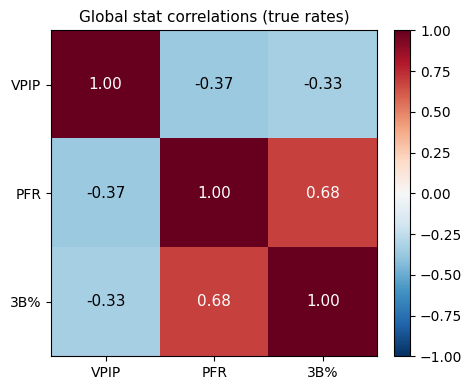

In [9]:
fig = plot_correlation_structure()
plt.show()

- Global correlations are driven by archetype structure: different player types cluster at different joint profiles
- Multi-stat updating exploits this: observing high VPIP shifts the posterior toward Fish or LAG, immediately adjusting expectations for PFR and 3B

### Archetype identification

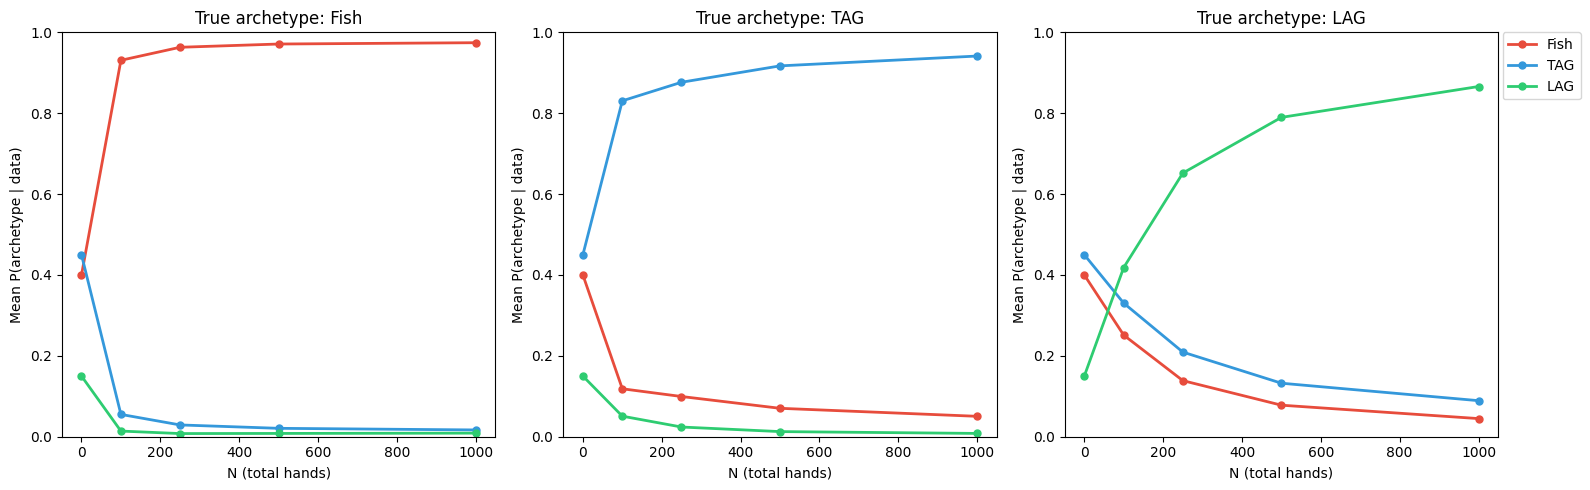

In [10]:
fig = plot_archetype_posteriors_line()
plt.show()

- At N=0 posteriors equal mixture weights (prior only); each line shows convergence as N grows
- Fish is identified quickly; TAG/LAG separation is slower due to overlap in VPIP/PFR space
- Each line averaged across 100 draws — individual variation averages out

### Stat informativeness

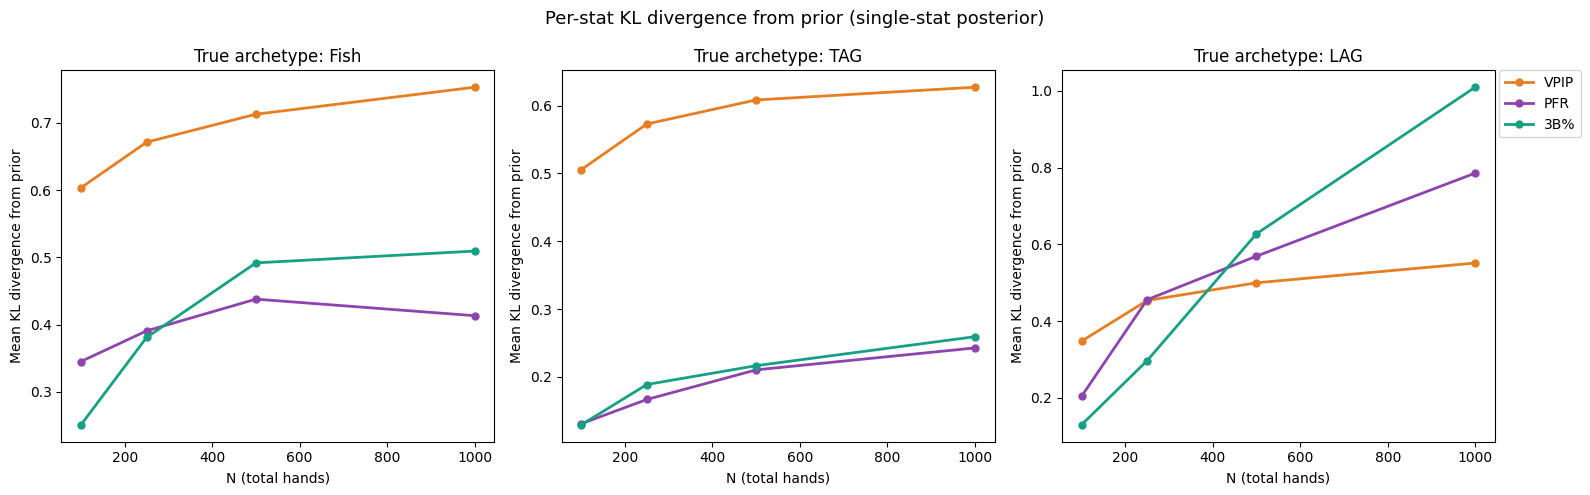

In [11]:
fig = plot_stat_informativeness()
plt.show()

- KL divergence from prior measures how much each stat alone shifts the archetype posterior — ordering-free measure of individual stat contribution
- VPIP dominates for Fish identification due to high opportunity rate and large between-archetype separation
- PFR and 3B become relatively more informative for TAG/LAG separation where VPIP alone is insufficient

### Estimation improvement by archetype

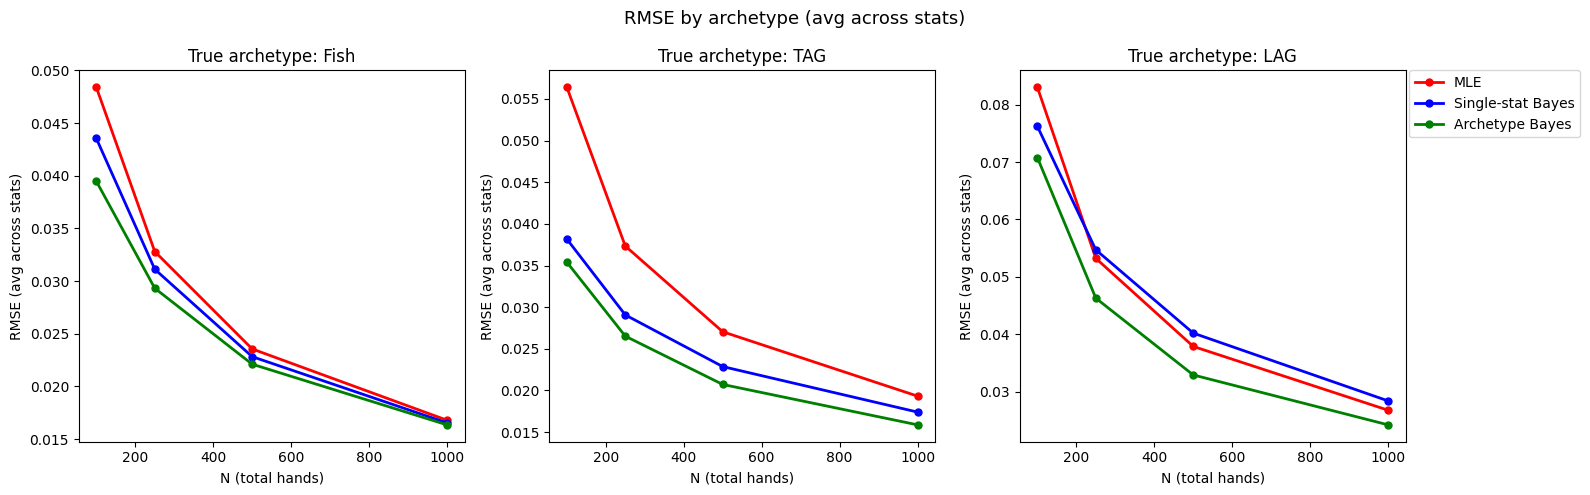

In [12]:
fig = plot_rmse_by_archetype()
plt.show()

- Archetype Bayes dominates MLE and single-stat Bayes at small N for all archetypes — shrinkage toward the correct archetype-conditional prior reduces variance
- For Fish and TAG, single-stat Bayes (population prior) also beats MLE at all N — the population prior is close enough to the archetype-conditional prior that bias is small
- For LAG, single-stat Bayes crosses above MLE at larger N — this is a specific failure mode: LAG is low-weight (15%) and has distinctive tendencies, so the population prior is systematically biased toward TAG/Fish. At small N, shrinkage still reduces variance enough to win; at large N, MLE variance is already low and the bias from the wrong prior dominates
- The archetype estimator avoids this failure mode entirely — once it identifies the player as LAG it conditions on the correct prior
- This mechanism highlights a practical implication: the single-stat estimator is most dangerous precisely for the players you most want to identify — rare archetypes with unusual tendencies

### Population-average RMSE

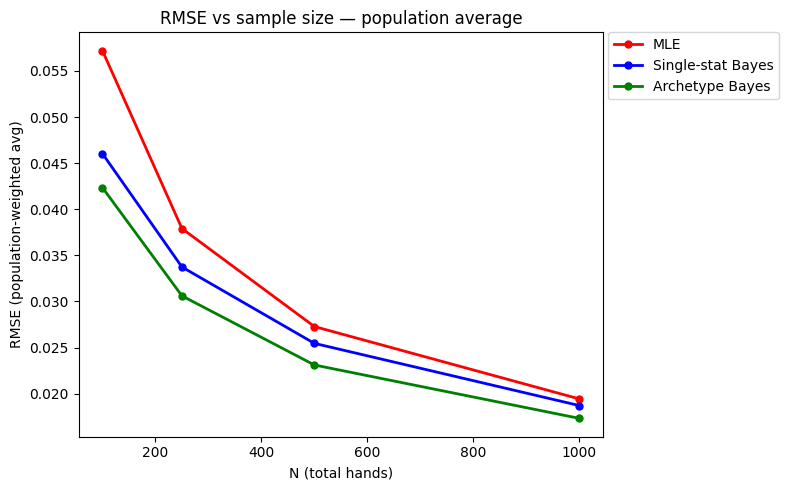

In [13]:
fig = plot_rmse_unconditional()
plt.show()

- Unconditionally across the full player pool, the ordering archetype Bayes ≤ single-stat Bayes ≤ MLE holds for all N
- The LAG failure mode washes out in the population average because LAG has only 15% mixture weight — this is why the unconditional picture looks clean even though the per-archetype picture reveals an important exception
- The gap between all three methods narrows as N grows, but archetype Bayes maintains an advantage throughout — the archetype posterior never stops being informative

### Motivation

- Zone tables shuffle players after every hand — no hand history accumulates even within a session; also relevant when aggregate stats are too thin
- We model a specific and common spot: BTN vs BB single-raised pot, villain out of position
- We abstract from bet sizes, stack sizes, timing tells, and other potential signals — actions only
- The game tree branches from preflop through to the river, but we only flesh out the branches needed to illustrate the three archetype identification paths below
- Large population samples for calibration are attainable (hand history databases); treat parameterisation as illustrative

### Decision tree

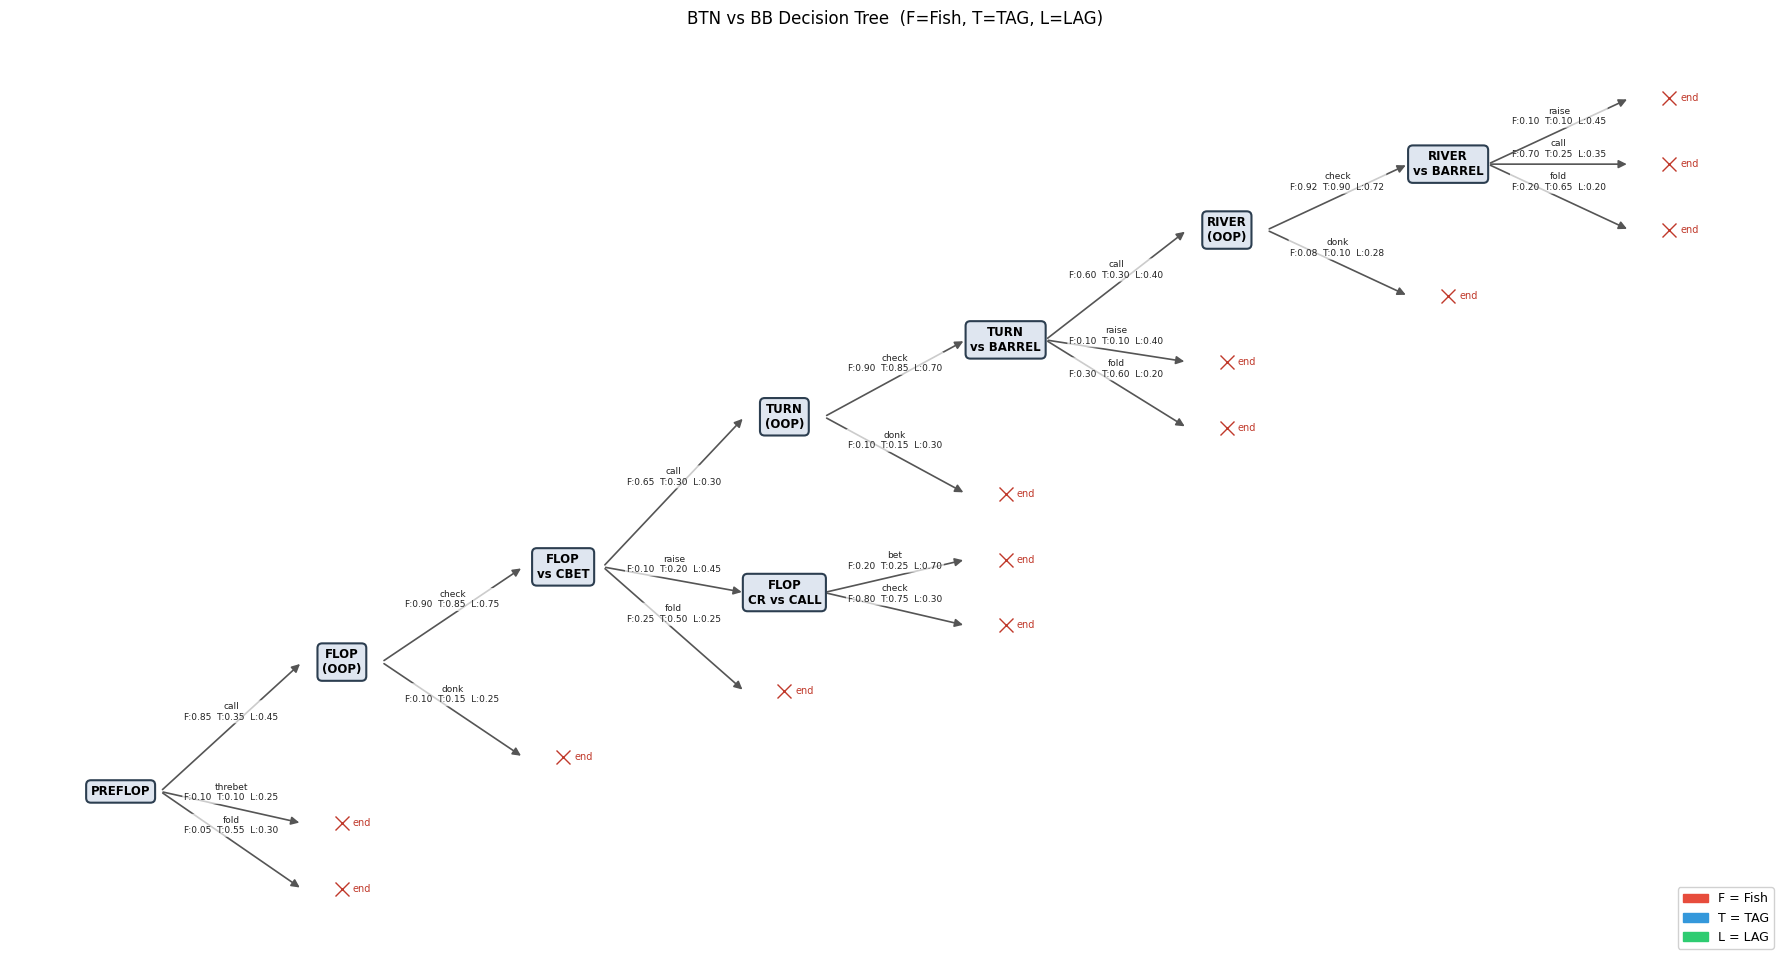

In [14]:
fig = plot_path_tree()
plt.show()

### Decision tree

### Posterior evolution

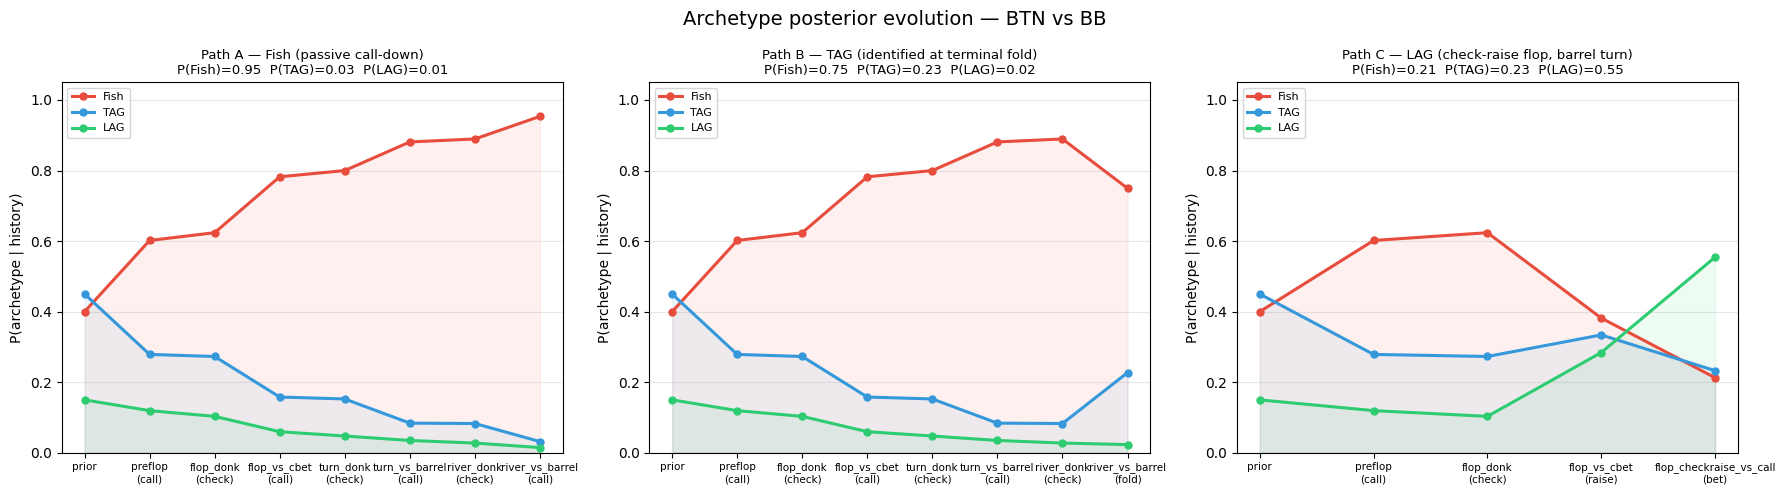

In [15]:
fig = plot_posterior_evolution()
plt.show()

- Path A (Fish): villain calls down passively through flop, turn, and river — posterior converges to Fish gradually, actionable read by turn for river bet sizing
- Path B (TAG): villain calls flop and turn but folds river barrel — TAG correctly identified, but only at the terminal fold. In zone poker there is no future hand to apply this read to — illustrates a fundamental limitation: some archetypes reveal themselves only through terminal actions
- Path C (LAG): villain check-raises flop, then barrels turn — flop check-raise shifts posterior toward LAG but TAG also check-raises with some frequency and has higher population weight, so separation is incomplete. Turn barrel resolves the ambiguity: LAG barrels at much higher frequency, posterior converges strongly to LAG. This is the most actionable path — read is established while the hand is live, informing our turn decision to fold

### Custom trace

In [16]:
paths = {
    "Check-raise flop, check turn (TAG or LAG?)": [
        ("preflop",                 "call"),
        ("flop_donk",               "check"),
        ("flop_vs_cbet",            "raise"),
        ("flop_checkraise_vs_call", "check"),
    ],
    "Call-call-raise river (Fish or LAG?)": [
        ("preflop",          "call"),
        ("flop_donk",        "check"),
        ("flop_vs_cbet",     "call"),
        ("turn_donk",        "check"),
        ("turn_vs_barrel",   "call"),
        ("river_donk",       "check"),
        ("river_vs_barrel",  "raise"),
    ],
}

for path_name, seq in paths.items():
    history, final = trace_path(seq)
    print(f"\n{'='*70}")
    print(f"  {path_name}")
    print(f"{'='*70}")
    header = (
        f"  {'Step':<4}  {'Node':<26}  {'Action':<12}  "
        + "  ".join(f"P({n})" for n in ARCHETYPE_NAMES)
    )
    print(header)
    print(f"  {'-'*68}")
    row_labels = [("prior", "-")] + list(seq)
    for i, (node, action) in enumerate(row_labels):
        probs = "  ".join(f"{history[i][k]:>7.3f}" for k in range(len(ARCHETYPE_NAMES)))
        print(f"  {i:<4}  {node:<26}  {action:<12}  {probs}")


  Check-raise flop, check turn (TAG or LAG?)
  Step  Node                        Action        P(Fish)  P(TAG)  P(LAG)
  --------------------------------------------------------------------
  0     prior                       -               0.400    0.450    0.150
  1     preflop                     call            0.602    0.279    0.119
  2     flop_donk                   check           0.624    0.273    0.103
  3     flop_vs_cbet                raise           0.382    0.334    0.284
  4     flop_checkraise_vs_call     check           0.476    0.391    0.133

  Call-call-raise river (Fish or LAG?)
  Step  Node                        Action        P(Fish)  P(TAG)  P(LAG)
  --------------------------------------------------------------------
  0     prior                       -               0.400    0.450    0.150
  1     preflop                     call            0.602    0.279    0.119
  2     flop_donk                   check           0.624    0.273    0.103
  3     flop_vs_

## Summary and Extensions

- Framework: Bayesian shrinkage outperforms raw frequencies at all sample sizes; archetype layer pools cross-stat information; within-hand updater handles anonymous case
- Limitations:
  - Independence within archetypes assumed — relax with full covariance matrix per archetype, calibrated from population data
  - All parameters estimable from large HUD databases
- Extension: archetype posterior feeds into EV calculations
  - High P(Fish) by river → higher EV for large value bet
  - Archetype posterior becomes input to decision model